# 04 — Labour-share accounting decomposition

This notebook consumes the processed Eurostat decomposition panel and does not
reimplement the accounting logic. The identity is

$$\Delta\log w = \Delta\log Y + \Delta\log s_L - \Delta\log N + (\pi_Y-\pi_C).$$

`w` is **real compensation per employee from national accounts**, not the OECD
average annual wage series. The two concepts are kept separate throughout: they
have different numerators, different denominators and different deflators.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from wage_transmission.decomposition import decompose_panel
from wage_transmission.plots import (
    plot_cumulative_decomposition,
    plot_decomposition_components,
)

INPUT = Path("../data/processed/decomposition_inputs.csv")
ILLUSTRATIVE = not INPUT.exists()

if not ILLUSTRATIVE:
    panel = pd.read_csv(INPUT)
else:
    # No processed decomposition input in this checkout. Build one from the
    # identity itself so the notebook still demonstrates that the accounting
    # closes. This is SIMULATED and is not evidence about any real economy.
    rng = np.random.default_rng(20260824)
    years = np.arange(1996, 2025)
    n = len(years)
    real_gdp = 100 * np.exp(np.cumsum(rng.normal(0.015, 0.02, n)))
    deflator = np.exp(np.cumsum(rng.normal(0.02, 0.01, n)))
    labour_share = 0.50 * np.exp(np.cumsum(rng.normal(-0.001, 0.006, n)))
    employees = 4000 * np.exp(np.cumsum(rng.normal(0.004, 0.008, n)))
    cpi = np.exp(np.cumsum(rng.normal(0.021, 0.009, n)))
    panel = pd.DataFrame(
        {
            "country": "PRT",
            "year": years,
            "real_gdp": real_gdp,
            "nominal_gdp": real_gdp * deflator,
            "employee_compensation": real_gdp * deflator * labour_share,
            "employees": employees,
            "consumer_price_index": cpi,
        }
    )

print("SIMULATED DATA — NOT EVIDENCE" if ILLUSTRATIVE else f"Source: {INPUT}")
panel.groupby("country").agg(
    first_year=("year", "min"), last_year=("year", "max"), n=("year", "size")
)

SIMULATED DATA — NOT EVIDENCE


,first_year,last_year,n
country,,,
PRT,1996,2024,29


In [2]:
portugal = panel.loc[panel["country"].eq("PRT")].copy()
components, summaries = decompose_panel(portugal)
summaries[0]

DecompositionSummary(country='PRT', start_year=1996, end_year=2024, n_growth_observations=28, observed_real_wage_log_change=0.13314552517976708, real_gdp_log_contribution=0.3439880159629629, labour_share_log_contribution=0.0078724927860232, employment_log_contribution=-0.06815588606654188, relative_price_log_contribution=-0.1505590975026765, decomposed_real_wage_log_change=0.13314552517976774, max_abs_identity_residual=1.942890293094024e-15)

## Annual contributions

Each row adds up: the four components reconstruct observed real wage growth.

In [3]:
components[
    [
        "year",
        "observed_real_wage_growth",
        "real_gdp_component",
        "labour_share_component",
        "employment_component",
        "relative_price_component",
        "identity_residual",
    ]
].tail(10).round(4)

,year,observed_real_wage_growth,real_gdp_component,labour_share_component,employment_component,relative_price_component,identity_residual
19,2015,0.0105,0.0026,0.0116,0.0019,-0.0056,-0.0
20,2016,-0.0014,0.0204,-0.0134,-0.0066,-0.0018,0.0
21,2017,-0.0250,0.0168,0.0023,-0.0153,-0.0288,0.0
22,2018,-0.0300,-0.0014,0.0041,0.0093,-0.0421,-0.0
23,2019,0.0204,0.0375,0.0004,-0.0109,-0.0067,0.0
24,2020,-0.0473,-0.0366,0.0006,-0.0011,-0.0102,0.0
25,2021,0.0260,0.0213,0.0014,0.0066,-0.0033,-0.0
26,2022,0.0210,0.0506,0.0030,-0.0131,-0.0195,0.0
27,2023,-0.0211,-0.0111,0.0013,-0.0117,0.0004,0.0
28,2024,0.0139,0.0276,0.0011,0.0076,-0.0223,0.0


## Does the identity close?

This is an accounting identity, so the residual must be zero to floating-point
tolerance. A non-trivial residual means the inputs are inconsistent — a mismatched
employee concept or deflator — not that the economy behaved unusually.

In [4]:
residual = components["identity_residual"].dropna()
print(f"Largest absolute residual: {residual.abs().max():.2e}")
print(f"Closes to tolerance      : {bool(residual.abs().max() < 1e-10)}")

Largest absolute residual: 1.94e-15
Closes to tolerance      : True


## Figures

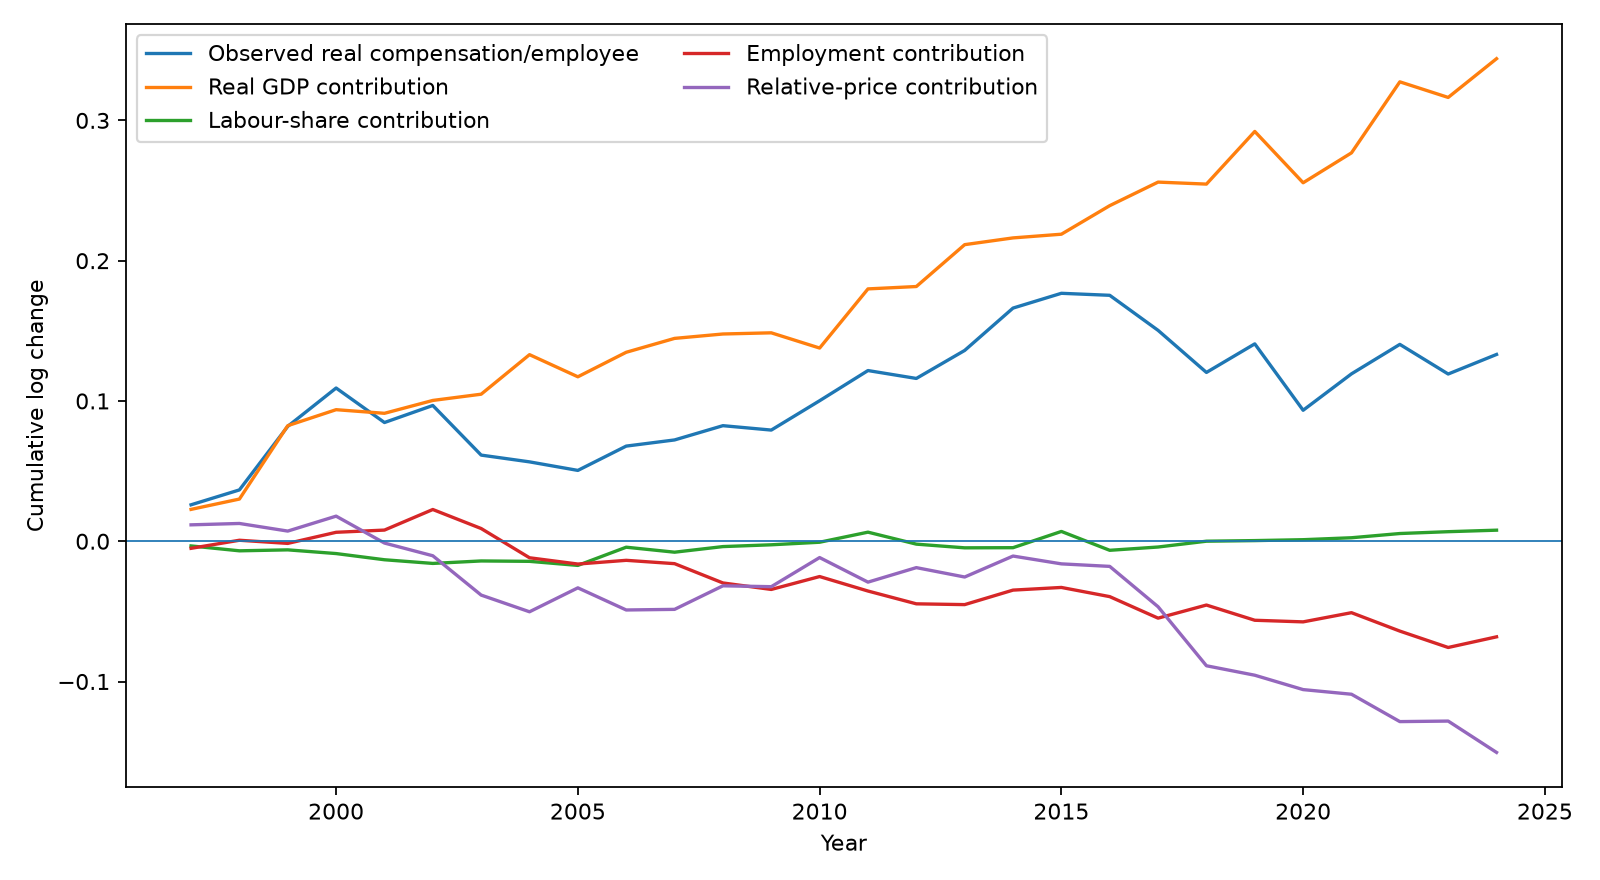

In [5]:
from IPython.display import Image

figure_dir = Path("../results/decomposition/PRT")
plot_decomposition_components(components, figure_dir / "annual_components.png")
plot_cumulative_decomposition(components, figure_dir / "cumulative_components.png")
Image(filename=str(figure_dir / "cumulative_components.png"))

## Interpretation guardrail

The decomposition is an accounting identity, not a causal model. A negative
labour-share contribution means the labour share moved against real compensation
per employee over the interval. It does **not** identify why the labour share
changed, and it cannot be read as the effect of any policy or shock.